# Event Types

This notebook performs the following steps to extract storm surge event types:

1. **Load data**  
   - Non-tidal residual (NTR) data are stored as `.pkl` files, each containing a `pandas.Series` with a datetime index.  
   - Station metadata is provided in a `stations_info.csv` file, which includes station name, longitude, and latitude, 70th percentile threshold.  
   - Additionally, we load `extremes_NTR.pkl`, which contains a list of `pandas.DataFrame` objects, each representing detected storm surge events for a station. Each dataframe has:
     - **Index**: Timestamps of event maxima (datetime index)  
     - **Columns**:
       - `max`: surge maximum of the event  
       - `duration`: event duration in hours  
       - `start`: datetime of the event start  
       - `end`: datetime of the event end  

2. **Extract storm surge hydrographs**  
   Event hydrographs have varying durations and sampling frequencies, so they are re-sampled to the same number of steps for clustering.

3. **Clustering of hydrographs**  
   A multi-step process is used to identify patterns in the storm surge hydrographs.

<br>

> The methodology is described in more detail in:  
> Pupić Vurilj, M. et al. *Storm surge hydrographs from historical observations of sea level along the Dutch North Sea coast.*  
> **Nat Hazards (2025).** [https://doi.org/10.1007/s11069-025-07351-8](https://doi.org/10.1007/s11069-025-07351-8)

**Figure:**  
*Methodology from the paper mentioned above. This notebook covers steps (iii) and (iv).*

<div align="center">
  <img src="assets/methodology.tiff" width="800">
</div>


## 1. Load Data

In [16]:
import pandas as pd

# Load station info (names,lon,lat)
stations = pd.read_csv("inputs/stations_info.csv", usecols=["station", "lon", "lat"])
stations

,station,lon,lat
0,Huibertgat,6.398433,53.573748
1,Schiermonnikoog,6.202908,53.468935
2,Eemshaven,6.828392,53.448699
3,Nes,5.758907,53.429936
4,Lauwersoog,6.196952,53.408684
5,West_Terschelling,5.220026,53.363043
6,Vlieland_Haven,5.091456,53.296125
7,Harlingen,5.409342,53.175632
8,Oudeschild,4.850192,53.038833
9,Den_Helder,4.744990,52.964357


In [17]:
# TODO: Check if this is correct to set stations as a global variable
# TODO for user: Change 2 to len(stations) and remove from pickle loading

import pickle

# Load non-tidal residual data per station in a list
NTR = []
for i in range(len(stations)):
    ntr_element = pd.read_pickle(f"inputs/NTR/ntr_{i}.pkl")
    # Append loaded data to lists
    NTR.append(ntr_element)

# Load POT events for each station (lists) using 70th percentile
with open("outputs/extremes_NTR.pkl", "rb") as f:
    # TODO: Check if this is correct to set extremes_NTR as a global variable
    globals()["extremes_NTR"] = pickle.load(f)

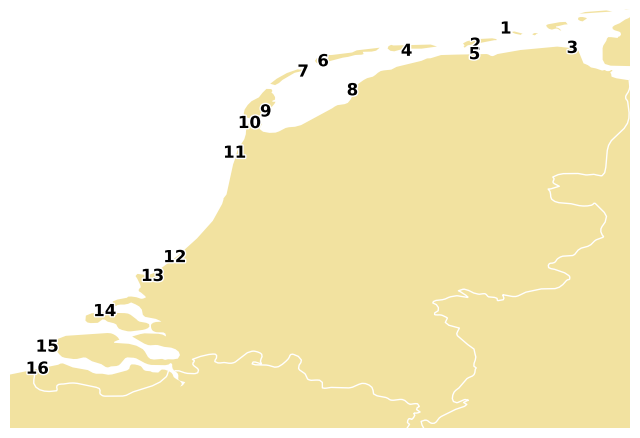

In [18]:
from utils.event_types import plot_stations

# Dutch coast extent [lon_min, lon_max, lat_min, lat_max]
coast_extent = [3.2, 7.2, 51, 53.7]
plot_stations(stations["lat"], stations["lon"], coast_extent)

## 2. Extract storm surge hydrographs

Distance-based clustering, such as K-medians, is a vector quantisation method that requires a constant number of dimensions. Therefore, the storm surge time series need to have the same number of time steps as they are used as features in clustering. Since the events in the dataset have varying time steps (∆t) and durations (D), it was necessary to normalise and interpolate the time series in time to allow for comparison of the different event shapes and durations

The hydrographs are extracted following these steps:

**a. Determine the maximum time interval for resampling**  
A regular time grid is defined using the chosen `max_interval`, which sets the number of time steps for each hydrograph.
$$
\Delta t_{\text{new}} = \frac{1}{\max(\Delta t \cdot D)}
$$

**b. Extract and normalise each event's time series**  
For each extreme event:
- The corresponding segment of the NTR time series is extracted between the event's **start** and **end** timestamps.
- The extracted time series is **normalised** allowing comparison across events of different durations.

**c. Resample the normalised time series**  
- Each normalised event is interpolated onto the regular time grid using **slinear (linear spline)** interpolation.

In [19]:
## Determine the maximum time interval for resampling
# this takes a few minutes to run

from utils.event_types import get_max_resample_interval, normalize_per_duration

max_interval, timeseries_max, idx_station, dt_max, dur_max = get_max_resample_interval(
    extremes_NTR, NTR
)

In [20]:
## Extract hydrographs

from utils.event_types import extract_hydrographs

hydrographs_NTR = extract_hydrographs(
    extremes_NTR, NTR, max_interval, normalize_per_duration
)

## 3. Clustering of hydrographs

Clustering is performed following these steps:

**a. Principal component analysis (PCA)**  
**Features:** Hydrograph + Event Duration  
Both features are weighted to contribute equally (50% each) to the variance in PCA.

**b. Maximum disimilarity algorithm (MDA)**  
Select a subset of 10% of the total data (4,584 events) to ensure a representative sample.

**c. K-Medians**  
Clustering of the MDA subset into 400 clusters using the K-medians algorithm (Wittek 2014), applying K-means++ as the initialization step.

**d. OPTICS**  
Clustering of the 400 centroids using the “Ordering Points To Identify the Clustering Structure” (OPTICS) (Ankerst et al. 1999) algorithm to merge some clusters.

**e. Refinement**   
Manual removal and merge based on Self-organising Maps (SOM) topology

### PCA

In [21]:
import xarray as xr
from utils.event_types import prepare_weighted_features

# Combined weighted feature matrix (hydrograph + duration) for clustering
features = prepare_weighted_features(extremes_NTR, hydrographs_NTR)
features_dataset = xr.Dataset(
    data_vars={"features": (("events", "timesteps"), features)},
    coords={"events": range(features.shape[0]), "timesteps": range(features.shape[1])},
)
features_dataset

<xarray.Dataset> Size: 413MB
Dimensions:    (events: 45843, timesteps: 1126)
Coordinates:
  * events     (events) int64 367kB 0 1 2 3 4 ... 45838 45839 45840 45841 45842
  * timesteps  (timesteps) int64 9kB 0 1 2 3 4 5 ... 1121 1122 1123 1124 1125
Data variables:
    features   (events, timesteps) float64 413MB 0.003502 0.002947 ... -1.074

In [22]:
from bluemath_tk.datamining.pca import PCA

# PCA
pca = PCA(
    n_components=0.99
)  # random_state=42 missing in the latest version of bluemath_tk
pca_reduced = pca.fit_transform(
    data=features_dataset,
    vars_to_stack=["features"],
    coords_to_stack=["timesteps"],
    pca_dim_for_rows="events",
)
pca_reduced

2025-10-01 08:13:56,650 - PCA - WARNING - Using 1126 out of 1126 available variables 
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 32MB
Dimensions:      (events: 45843, n_component: 85)
Coordinates:
  * events       (events) int64 367kB 0 1 2 3 4 ... 45839 45840 45841 45842
  * n_component  (n_component) int64 680B 0 1 2 3 4 5 6 ... 78 79 80 81 82 83 84
Data variables:
    PCs          (events, n_component) float64 31MB -0.7998 9.813 ... -0.04522
    stds         (n_component) float64 680B 19.43 13.05 10.53 ... 0.5757 0.5608

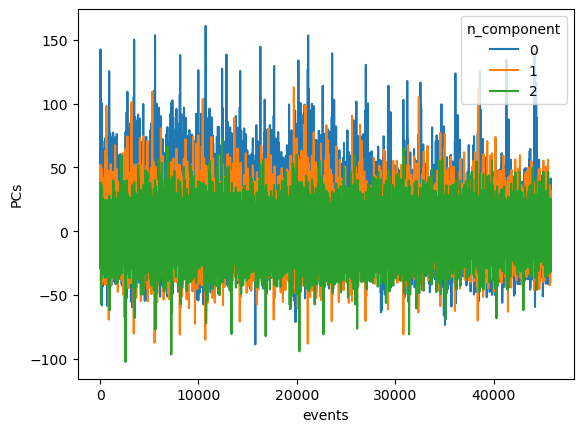

In [23]:
pca.plot_pcs(num_pcs=3)

### MDA

(<Figure size 640x480 with 3 Axes>,
 array([[<Axes: xlabel='PC2', ylabel='PC1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='PC3', ylabel='PC2'>]], dtype=object))

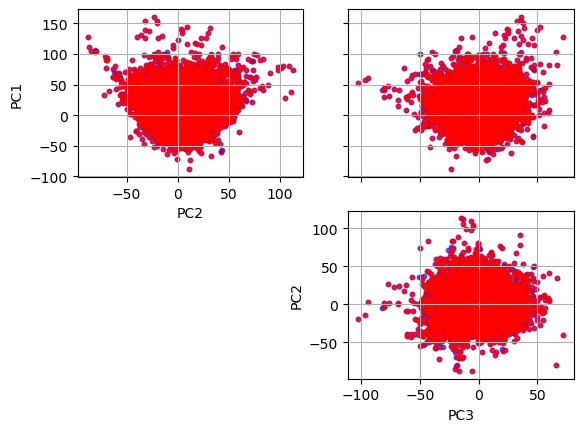

In [24]:
from bluemath_tk.datamining.mda import MDA

mda = MDA(num_centers=4584)  # 4584
nearest_centroids_idxs, nearest_centroids_df = mda.fit_predict(
    data=pca.pcs_df.iloc[:, :3]
)

mda.plot_selected_centroids(plot_text=False)

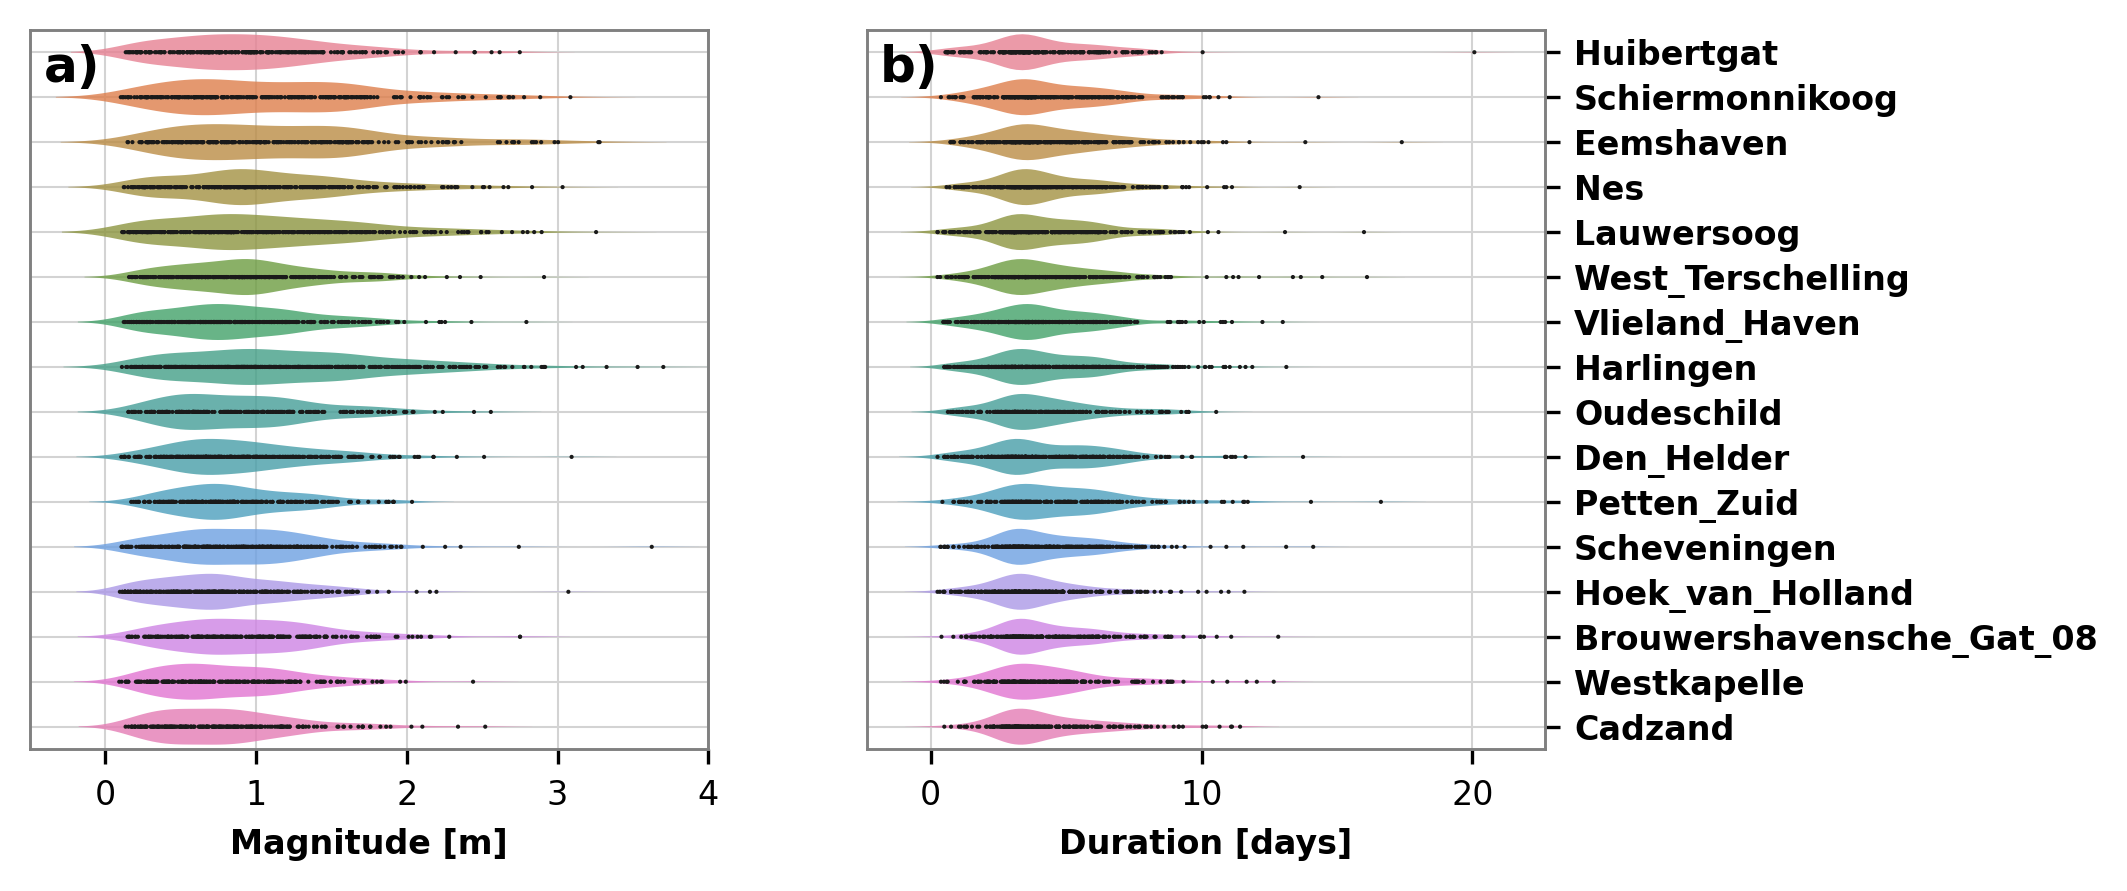

In [25]:
from utils.event_types import (
    count_events_per_station,
    extract_chosen_events,
    plot_magnitude_duration_violin,
)

# Info about chosen events
selected = extract_chosen_events(
    mda.centroid_real_indices, extremes_NTR, hydrographs_NTR, stations["station"]
)
station_event_counts = count_events_per_station(selected)

# Plot distribution per station for MDA subset
plot_magnitude_duration_violin(
    chosen_events=selected, station_names=stations["station"]
)

### K-medians (pyclustering)

In [26]:
from pyclustering.cluster.kmedians import kmedians
from sklearn.cluster import kmeans_plusplus

k = 400  # number of clusters (around 10% of MDA subset)

initial_medians, indexes = kmeans_plusplus(
    mda.data.values, n_clusters=k, random_state=42
)
# initial_medians = np.random.rand(k, selected_events.shape[1])

kmedians_instance = kmedians(
    data=mda.data.values, initial_medians=initial_medians, amount_clusters=k
)

# Run KMedians clustering
kmedians_instance.process()

# Retrieve cluster labels
kmed_labels = kmedians_instance.get_clusters()

### OPTICS

OPTICS is a density-based clustering algorithm.


In [27]:
import numpy as np
from sklearn.cluster import OPTICS
from sklearn.metrics import pairwise_distances

centroids = np.array(kmedians_instance.get_medians())

# Timeseries closest to the centroid (medoid)
closest_points = []
closest_point_indices = []
for centroid in centroids:
    distances = pairwise_distances(mda.data.values, [centroid], metric="manhattan")
    closest_point_index = np.argmin(distances)
    closest_points.append(mda.data.values[closest_point_index])
    closest_point_indices.append(closest_point_index)

closest_points = np.array(closest_points)

# Apply OPTICS clustering to the medoid
optics = OPTICS(min_samples=2, xi=0)  # Adjust parameters as needed
optics.fit(closest_points)

# Retrieve the cluster labels from OPTICS
optics_labels = optics.labels_

num_noise_points = np.sum(optics_labels == -1)
max_optics_clusters = max(optics_labels)
print("Number of noise points:", num_noise_points)
print("Number of clusters:", max_optics_clusters)

Number of noise points: 133
Number of clusters: 103


In [28]:
from utils.event_types import merge_kmedians_with_optics

## Merge K-medians clusters based on OPTICS results
merged_labels = merge_kmedians_with_optics(kmed_labels, optics_labels)
merged_labels

[[24576,
  40961,
  32773,
  8208,
  8212,
  16410,
  26,
  24605,
  31,
  24612,
  55,
  24634,
  8254,
  16450,
  32835,
  24644,
  16462,
  16469,
  8288,
  110,
  41073,
  32884,
  32887,
  16507,
  32891,
  32897,
  32907,
  24719,
  41110,
  16536,
  24730,
  24731,
  24734,
  32936,
  169,
  16556,
  32940,
  175,
  16560,
  16561,
  32949,
  41150,
  41155,
  196,
  24776,
  24784,
  16594,
  8406,
  16600,
  24801,
  16611,
  41207,
  33017,
  8446,
  41215,
  41216,
  41219,
  8461,
  33037,
  41233,
  33042,
  16659,
  8493,
  24883,
  16700,
  24900,
  16725,
  41306,
  8540,
  41311,
  8543,
  8546,
  357,
  24934,
  24941,
  8559,
  24943,
  33147,
  383,
  41349,
  24978,
  8595,
  16790,
  16793,
  410,
  412,
  41375,
  24992,
  8610,
  24995,
  16815,
  25008,
  16816,
  25029,
  461,
  471,
  8665,
  25054,
  16863,
  8676,
  25062,
  41451,
  33259,
  16879,
  33264,
  33265,
  8688,
  25075,
  16895,
  16899,
  25092,
  8720,
  529,
  8729,
  41501,
  543,
  41511,

### Refinement

In [29]:
# from utils.refinement import (
#     filter_clusters_by_removal_and_centroid,
#     manual_merge_step_one,
#     manual_merge_step_three,
#     manual_merge_step_two,
# )

# # Manual removal and filter centroid maxima > 1
# filtered_clusters = filter_clusters_by_removal_and_centroid(
#     merged_labels, hydrographs_NTR, pd.Series(mda.centroid_real_indices)
# )

# # Manual merge
# step1 = manual_merge_step_one(filtered_clusters)
# step2 = manual_merge_step_two(step1)
# manual_merge_clusters = manual_merge_step_three(step2)

# # Filter out clusters with less than 5 timeseries
# final_clusters = [labels for labels in manual_merge_clusters if len(labels) >= 5]

### Clusters plot

In [30]:
# from utils.event_types import plot_clusters_NTR_only

# plot_clusters_NTR_only(
#     final_clusters, hydrographs_NTR, pd.Series(mda.centroid_real_indices)
# )